#### Exercise 2
Hugo Lladró Prats, Inés Mang Román, Ahmet Meriç Kızıltaş

In [ ]:
!mamba install scikit-image

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski

a) Load the original image (top row of Fig. 1) and take its logarithm. Make sure that your code
never attempts to take the logarithm of zero. (2P)

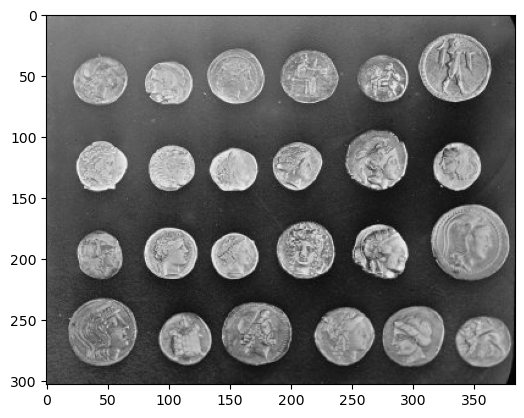

In [21]:
image = ski.img_as_float(ski.data.coins()) + 0.001
log_image = np.log(image)
plt.imshow(image, cmap = 'gray')

b) Compute the logarithms of at least two different smoothed versions of the image, selecting suitable
scales. (2P)

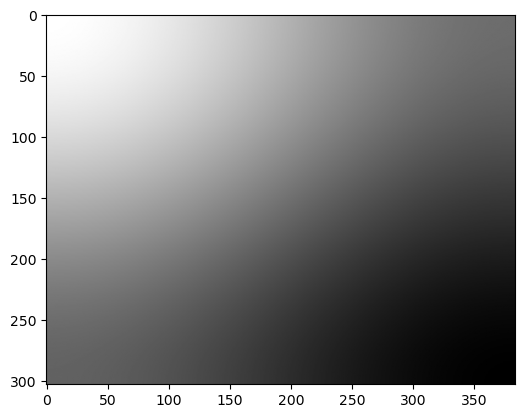

In [18]:
from scipy.ndimage import gaussian_filter

smooth_image_1 = gaussian_filter(image, 10)
smooth_image_2 = gaussian_filter(image, 200)
smooth_log_1 = np.log(smooth_image_1)
smooth_log_2 = np.log(smooth_image_2)

c) Evaluate Eq. (1) and plot the resulting retinex image F after converting it back to the expected
numerical range of an image via min-max-scaling. At this point, your result might look similar
to the one in the middle row of Fig. 1, i.e., the contrast might still be worse than in the original.
(2P)


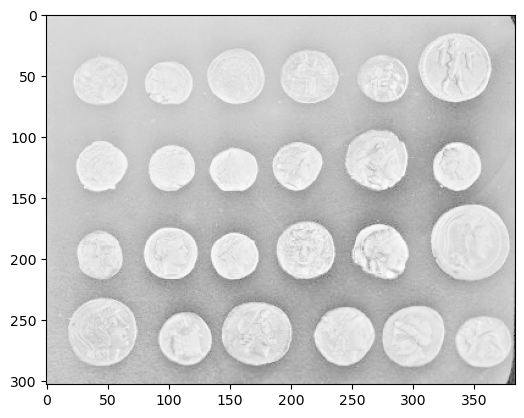

In [31]:
processed_image = 3*log_image-smooth_log_1-2*smooth_log_2
min_val = np.min(processed_image)
max_val = np.max(processed_image)
retinex_image = (processed_image-min_val)/(max_val-min_val)
plt.imshow(retinex_image, cmap = 'gray')

d) Perform an alternative re-scaling of the retinex image by clipping some small percentage of the
most extreme values, instead of just taking the minimum and maximum. Your result should now
look similar to the bottom row of Fig. 1. (2P)

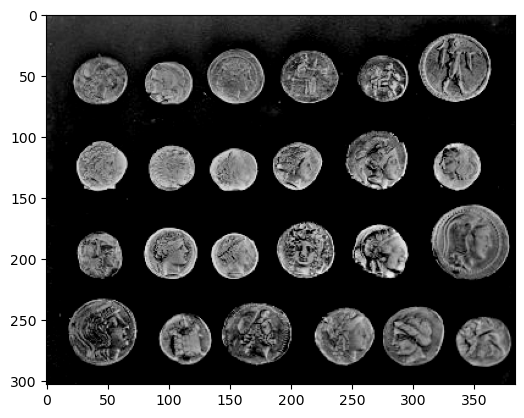

In [40]:
alpha = 0.01
retinex_image_2 = (processed_image-alpha*min_val)/(max_val-alpha*min_val)
retinex_image_2 = np.clip(retinex_image_2, 0, 1)
plt.imshow(retinex_image_2, cmap = 'gray')